In [1]:
import numpy as np
import os
import pandas as pd
from matplotlib import pyplot as plt

### Plot error scaling

Function: inner product - sigmoid -  avg over 10 x's - weighted avg

In [2]:
def make_canvas(
    axes_width_pt: float = 300.0,
    axes_aspect: float = 2/3,
    left_pt: float = 40.0,
    right_pt: float = 20.0,
    bottom_pt: float = 35.0,
    top_pt: float = 20.0,
    fontsize: float = 8.0,
):
    _PT_PER_IN = 72.0
    # Use PDF “base 14” fonts (Helvetica) — no TTF embedding, no fontTools warnings
    plt.rcParams.update({
        "pdf.use14corefonts": True,   # key line
        "ps.useafm": True,            # for .ps if you ever use it
        # Do NOT set pdf.fonttype/ps.fonttype when using core fonts
        "text.usetex": False,         # set True only if you want LaTeX (see Option C)
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica"],
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
    })
    # Make math text look sans-ish to match Helvetica
    plt.rcParams.update({
        "mathtext.fontset": "stixsans",
    })

    axes_h_pt = axes_width_pt * float(axes_aspect)
    fig_w_pt = left_pt + axes_width_pt + right_pt
    fig_h_pt = bottom_pt + axes_h_pt + top_pt

    fig = plt.figure(figsize=(fig_w_pt/_PT_PER_IN, fig_h_pt/_PT_PER_IN))
    ax = fig.add_axes([
        left_pt/fig_w_pt,
        bottom_pt/fig_h_pt,
        axes_width_pt/fig_w_pt,
        axes_h_pt/fig_h_pt,
    ])
    # ax.grid(True, which="both", linestyle=":", linewidth=0.5)
    return fig, ax

In [4]:
def load_and_aggregate(csv_path: str) -> pd.DataFrame:
    # Load
    df = pd.read_csv(csv_path)
    # Ensure types
    df["m"] = df["m"].astype(int)
    df["k"] = df["k"].astype(int)
    df["d"] = df["d"].astype(int)
    df["orig"] = pd.to_numeric(df["orig"], errors="coerce")
    df["comp"] = pd.to_numeric(df["comp"], errors="coerce")

    # Compute absolute error
    df["abs_err"] = (df["comp"] - df["orig"]).abs()

    # Aggregate over repetitions for identical (m,k,d)
    agg = (
        df.groupby(["m", "k", "d"], as_index=False)["abs_err"]
          .agg(mean="mean", std="std", count="size")
    )
    # std is NaN when count==1; replace with 0 for plotting
    agg["std"] = agg["std"].fillna(0.0)
    return agg

def make_plots(agg: pd.DataFrame, outdir: str, show: bool=False, tol=5e-15, **kwargs):
    os.makedirs(outdir, exist_ok=True)
    for m in sorted(set(agg["m"])):
        fig, ax = make_canvas(**kwargs)

        # Plot 6 lines for k = 1..6 (skip missing k’s gracefully)
        for k in range(1, 7):
            g = agg[(agg["m"] == m) & (agg["k"] == k)].copy()
            if g.empty:
                continue
            g = g.sort_values("d")
            # Only plot points where mean > tol
            g = g[g["mean"] > tol]
            if g.empty:
                continue

            ax.errorbar(
                g["d"].to_numpy(),
                g["mean"].to_numpy(),
                yerr=g["std"].to_numpy(),
                fmt="o-",
                markersize=3,
                capsize=3,
                label=rf"$k={k}$",
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"$d$")
        ax.set_ylabel(r"$\left|f(\theta) - f(\theta')\right|$")
        ax.set_title(rf"$m = {m}$")
        # ax.legend(ncols=3)
        # ax.grid(True, which="both", linestyle=":", linewidth=0.5)

        outpath = os.path.join(outdir, f"errors_m{m}.pdf")
        fig.tight_layout()
        # fig.savefig(outpath, bbox_inches="tight", pad_inches=0)
        if show:
            plt.show()
        plt.close(fig)


def fit_alpha(agg: pd.DataFrame, tol: float = 5e-15) -> pd.DataFrame:
    r"""
    For each (m,k), fit \alpha from the ansatz: mean(d) = c d^{-\alpha}.
    Discard any (m,k,d) with mean <= tol before fitting (default tol=5e-15).
    OLS on logs: y = a + b x with x=log(d), y=log(mean); alpha = -b, std(alpha)=SE(b).
    """
    rows = []
    for (m, k), g in agg.groupby(["m", "k"]):
        # keep only valid d and mean, and enforce mean > tol
        g = g[
            np.isfinite(g["mean"]) & (g["mean"] > tol)
            & ~(m == 4 & g["k"].isin([5, 6]) & g["d"].isin([1000]))
        ]
        if len(g) < 2:
            continue

        x = np.log(g["d"].to_numpy(dtype=float))
        y = np.log(g["mean"].to_numpy(dtype=float))

        xbar = x.mean()
        ybar = y.mean()
        Sxx = np.sum((x - xbar) ** 2)
        if Sxx <= 0:
            continue
        Sxy = np.sum((x - xbar) * (y - ybar))

        b = Sxy / Sxx            # slope
        a = ybar - b * xbar      # intercept
        yhat = a + b * x
        resid = y - yhat

        dof = max(len(x) - 2, 1)
        s2 = np.sum(resid ** 2) / dof
        se_b = np.sqrt(s2 / Sxx)

        rows.append({
            "m": int(m),
            "k": int(k),
            "alpha": float(-b),
            "alpha_std": float(se_b),
            "n_points": int(len(x)),
        })

    return pd.DataFrame(rows)

def make_alpha_plot(alpha_df: pd.DataFrame, outpath: str, show: bool, **kwargs):
    """
    Plot alpha (with error bars) vs k, with four lines corresponding to m=1,2,3,4.
    """
    os.makedirs(os.path.dirname(outpath) or ".", exist_ok=True)
    fig, ax = make_canvas(**kwargs)

    for m in [3,]:
        g = alpha_df[alpha_df["m"] == m].sort_values("k")
        if g.empty:
            continue
        ax.errorbar(
            g["k"].to_numpy(),
            g["alpha"].to_numpy(),
            yerr=g["alpha_std"].to_numpy(),
            fmt="o-",
            markersize=3,
            capsize=3,
            label=rf"$m={m}$",
        )
        # theory line alpha = 2-(k+1)/m
        ax.plot(g["k"].to_numpy(), 
                (g["k"].to_numpy() + 1) / m + 0.5,
                linestyle="--", color=ax.lines[-1].get_color(),
                # label=rf"theory $m={m}$"
                )

    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$\alpha$")
    # ax.set_title(r"Fit of $\left\langle\left|\,\mathrm{comp}-\mathrm{orig}\,\right|\right\rangle \sim c\, d^{-\alpha}$")
    # ax.grid(True, which="both", linestyle=":", linewidth=0.5)
    ax.legend(title="", ncols=1)

    fig.tight_layout()
    # fig.savefig(outpath, bbox_inches="tight", pad_inches=0)
    if show:
        plt.show()
    plt.close(fig)


/var/folders/3h/bnfdmp3n4jxctbk9z3l__ns40000gn/T/ipykernel_83369/2741359374.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


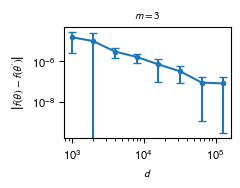

/var/folders/3h/bnfdmp3n4jxctbk9z3l__ns40000gn/T/ipykernel_83369/2741359374.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


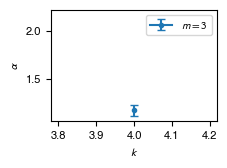

In [7]:
plot_size = {
    "axes_width_pt": 120,
    "axes_aspect": 2/3,
    "left_pt": 15,
    "right_pt": 10,
    "bottom_pt": 15,
    "top_pt": 10,
    "fontsize": 8,
}

agg = load_and_aggregate("sqrt_error_list.csv")
make_plots(agg, ".", True, **plot_size)
alpha_df = fit_alpha(agg)
make_alpha_plot(alpha_df, "error_alpha.pdf", True, **plot_size)